In [647]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, aberration, equatorial2galactic, galactic2equatorial
import os
import numpy as np
import matplotlib.pyplot as plt
import math

In [587]:
sim = Simulation("TED")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

position = 1000
dim = 100
numSubPixels = sim["SubField/SubPixels"]

sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = position - dim // 2
sim["SubField/ZeroPointColumn"] = position - dim // 2
    

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "yes"

sim["Telescope/UseDrift"] = "yes"
sim["Telescope/UseDriftFromFile"] = "yes"

In [588]:
driftTimeScale = 0.1
drift = 50

numDriftSteps = int(25 / driftTimeScale) * 500
time = np.arange(numDriftSteps) * driftTimeScale
noChange = np.zeros(numDriftSteps)
change = np.arange(numDriftSteps) * drift

driftFilenameYaw = os.environ["PLATO_WORKDIR"] + "yawDrift.txt"
driftFilenamePitch = os.environ["PLATO_WORKDIR"] + "pitchDrift.txt"
driftFilenameRoll = os.environ["PLATO_WORKDIR"] + "rollDrift.txt"

np.savetxt(driftFilenameYaw, np.c_[time, change, noChange, noChange])
np.savetxt(driftFilenamePitch, np.c_[time, noChange, change, noChange])
np.savetxt(driftFilenameRoll, np.c_[time, noChange, noChange, change])

sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [589]:
drift2 = drift

driftTimeScale2 = 25
numDriftSteps2 = int(25 / driftTimeScale2) * 500
time2 = np.arange(numDriftSteps2) * driftTimeScale2
noChange2 = np.zeros(numDriftSteps2)
change2 = np.arange(numDriftSteps2) * drift2

driftFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawDrift2.txt"
driftFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchDrift2.txt"
driftFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollDrift2.txt"

np.savetxt(driftFilenameYaw2, np.c_[time2, change2, noChange2, noChange2])
np.savetxt(driftFilenamePitch2, np.c_[time2, noChange2, change2, noChange2])
np.savetxt(driftFilenameRoll2, np.c_[time2, noChange2, noChange2, change2])

# Change in yaw only (exaggerated)

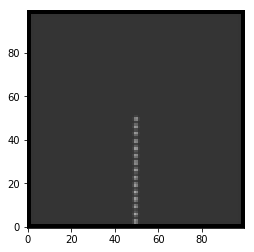

In [590]:
sim["Telescope/DriftFileName"] = driftFilenameYaw

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [591]:
sim["Telescope/DriftFileName"] = driftFilenameYaw2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000015 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

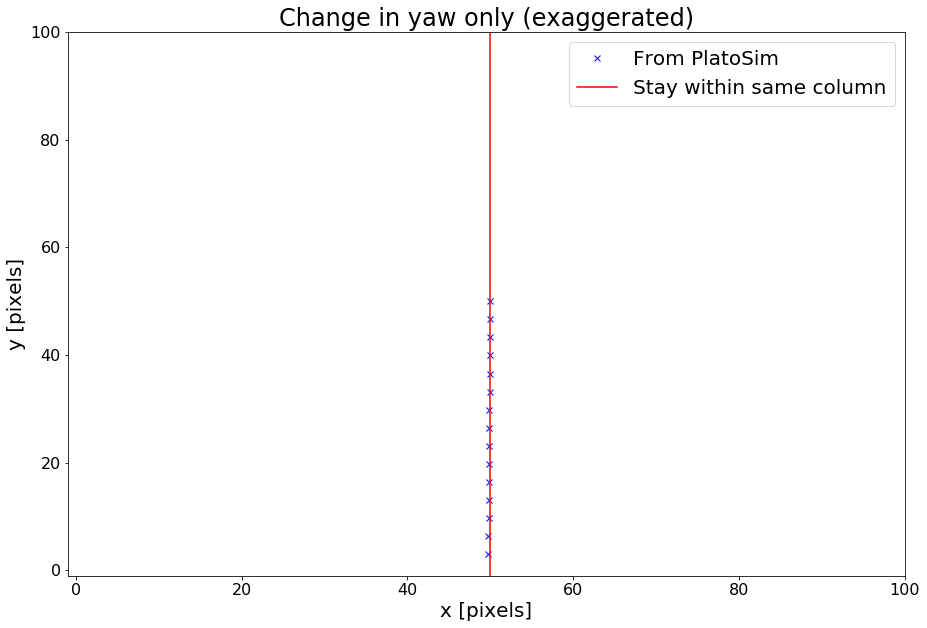

In [595]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(60):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")

    
    
###############
# Change in row
###############

plt.axvline(x = dim / 2, color = "r", label = "Stay within same column")



########
# Layout
#######

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.title("Change in yaw only (exaggerated)", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in pitch only (exaggerated)

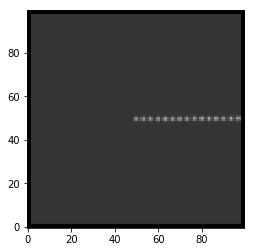

In [596]:
sim["Telescope/DriftFileName"] = driftFilenamePitch

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [597]:
sim["Telescope/DriftFileName"] = driftFilenamePitch2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Error: SimfFile.getStarCoordinates(): Exposure000015 not in hdf5 file


Text(0, 0.5, 'y [pixels]')

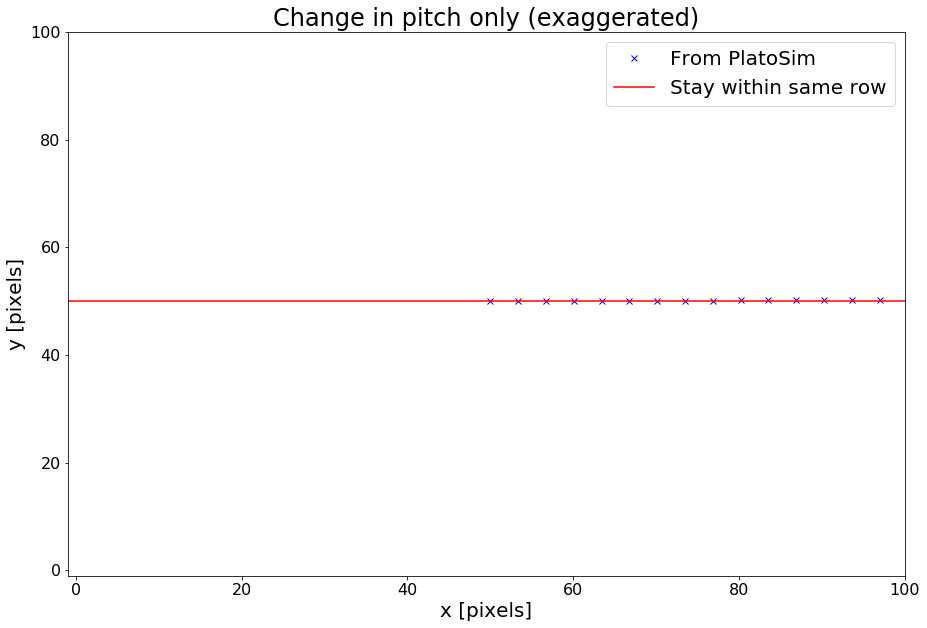

In [598]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")



##################
# Change in column
##################

plt.axhline(y = dim / 2, color = "r", label = "Stay within same row")

    
    
########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.title("Change in pitch only (exaggerated)", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)

# Change in roll only (exaggerated)

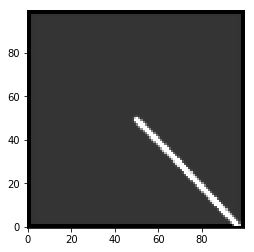

In [599]:
sim["Telescope/DriftFileName"] = driftFilenameRoll

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [600]:
sim["Telescope/DriftFileName"] = driftFilenameRoll2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Text(0, 0.5, 'y [pixels]')

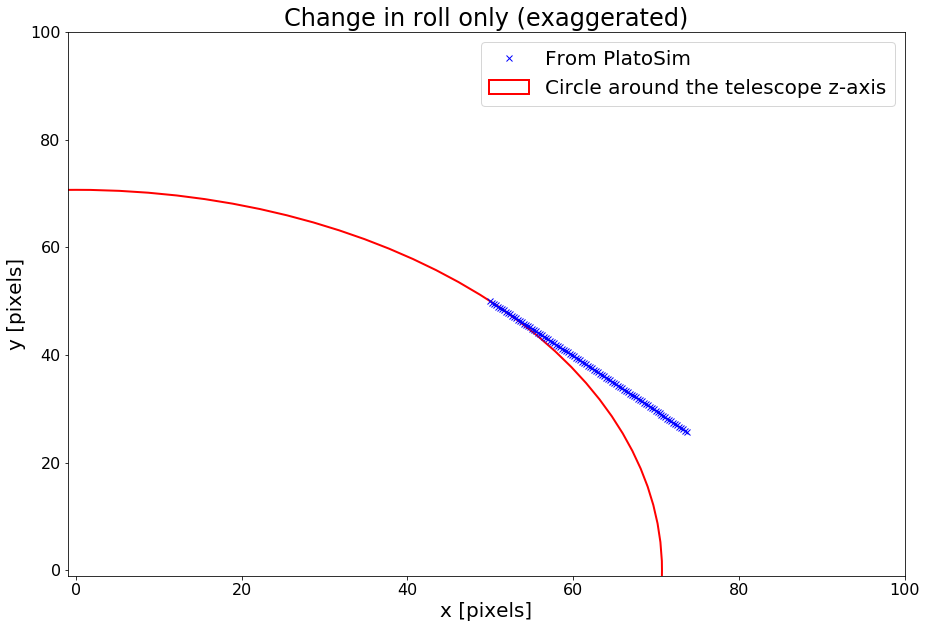

In [654]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns, rows, "bx", label = "From PlatoSim")



########
# Circle
########

circ = plt.Circle((0,0), radius = math.sqrt(radiusSquared), color = "white", linewidth = 2, label = "Circle around the telescope z-axis")
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")



########
# Layout
########

plt.xlim([-1, dim])
plt.ylim([-1, dim])

plt.title("Change in roll only (exaggerated)", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("x [pixels]", fontsize = 20)
plt.ylabel("y [pixels]", fontsize = 20)